# Relatórios e Testes da IA (U-Net)

Este notebook é dedicado à avaliação do modelo U-Net treinado para segmentação de Esclerose Múltipla. Ele foca na visualização do histórico de treinamento, realização de inferências visuais em imagens e testes quantitativos do modelo.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import numpy as np
from PIL import Image
import os
from torchvision import transforms
from model import UNet
import random

## 1. Relatório de Treinamento

Aqui analisamos a evolução da função de perda (Loss) e da métrica Dice Score ao longo das épocas de treinamento, carregando os dados do arquivo `training_history.csv`.

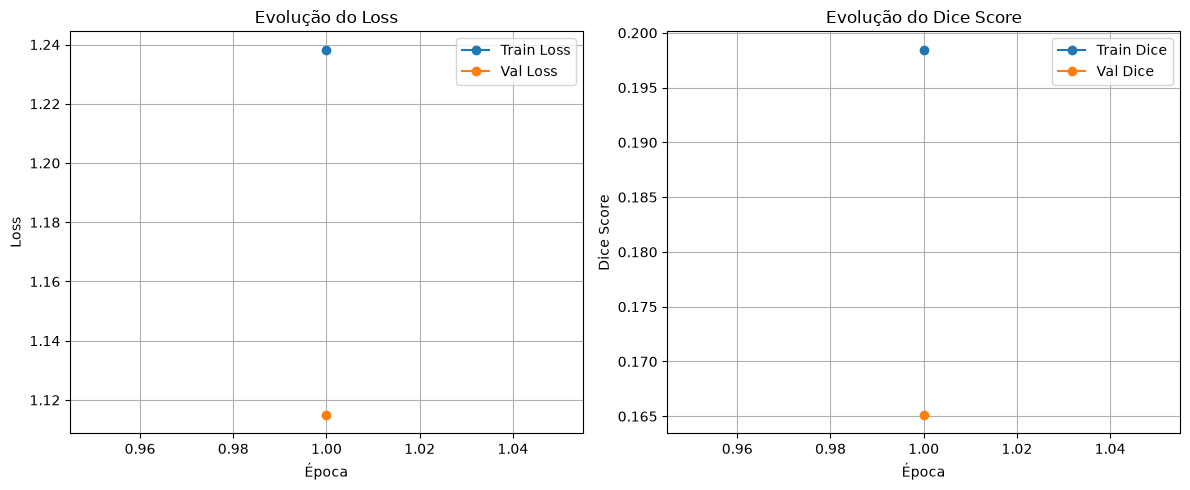

In [3]:
try:
    df = pd.read_csv('training_history.csv')
    
    plt.figure(figsize=(12, 5))
    
    # Gráfico de Loss
    plt.subplot(1, 2, 1)
    plt.plot(df['epoch'], df['train_loss'], label='Train Loss', marker='o')
    if 'val_loss' in df.columns:
        plt.plot(df['epoch'], df['val_loss'], label='Val Loss', marker='o')
    plt.title('Evolução do Loss')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()
    
    # Gráfico de Dice Score
    plt.subplot(1, 2, 2)
    plt.plot(df['epoch'], df['train_dice'], label='Train Dice', marker='o')
    if 'val_dice' in df.columns:
        plt.plot(df['epoch'], df['val_dice'], label='Val Dice', marker='o')
    plt.title('Evolução do Dice Score')
    plt.xlabel('Época')
    plt.ylabel('Dice Score')
    plt.grid(True)
    plt.legend()
    
    plt.tight_layout()
    plt.show()
except FileNotFoundError:
    print("Arquivo training_history.csv não encontrado.")

### LOSS

O gráfico apresenta a evolução da função de perda (Loss) durante o treinamento da U-Net. Essa métrica indica o erro cometido pelo modelo ao comparar a segmentação predita com a máscara real. O comportamento esperado é uma redução progressiva dos valores ao longo das épocas, demonstrando que a rede está aprendendo a segmentar as lesões de forma cada vez mais precisa. Além disso, é desejável que as curvas de treinamento e validação permaneçam próximas, indicando boa capacidade de generalização e reduzindo o risco de overfitting.

### DICE SCORE

Este gráfico mostra a evolução do Dice Score durante o treinamento e validação do modelo. O Dice Score mede a similaridade entre a máscara predita pela rede e a máscara real, variando entre 0 e 1, sendo 1 a correspondência perfeita. O comportamento ideal consiste em um aumento gradual dessa métrica ao longo das épocas, acompanhado de valores semelhantes entre treinamento e validação, indicando que o modelo está aprendendo de forma consistente e generalizando adequadamente para novos dados.

## 2. Preparação do Modelo para Testes

Carregamos a arquitetura do modelo (`UNet`), restauramos os pesos aprendidos (`unet_mri_model.pth`) e configuramos as transformações necessárias para a inferência (redimensionamento e conversão para tensor).

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilizando dispositivo: {device}")

# Inicializar e Carregar Modelo
model = UNet()
try:
    
    checkpoint = torch.load("unet_mri_model.pth", map_location=device)
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)

    print("Pesos do modelo carregados com sucesso!")
except Exception as e:
    print(f"Aviso: Erro ao carregar os pesos do modelo: {e}")

model.to(device)
model.eval() # Modo de avaliação, desliga dropout/batchnorm

# Transformações compatíveis com o treinamento
img_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

mask_transform = transforms.Compose([
    transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.ToTensor()
])

Utilizando dispositivo: cpu
Pesos do modelo carregados com sucesso!


## 3. Teste Visual (Inferência Direta)

Esta função permite escolher uma imagem aleatória do dataset de teste para comparar visualmente a Imagem Original, a Máscara Real (Ground Truth) e a Máscara Predita pelo modelo.

In [7]:
def predict_and_visualize(image_path, mask_path=None):
    # Carrega e processa a imagem original
    image = Image.open(image_path).convert("L")
    input_tensor = img_transform(image).unsqueeze(0).to(device)
    
    # Realiza a predição (inferência)
    with torch.no_grad():
        output = model(input_tensor)
        
    # Passa a saída pela sigmoid e aplica um threshold de 0.5
    pred_mask = (torch.sigmoid(output) > 0.5).float()
    pred_mask = pred_mask.squeeze().cpu().numpy()
    
    # Prepara o plot
    num_plots = 3 if mask_path and os.path.exists(mask_path) else 2
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, num_plots, 1)
    plt.title('Imagem Original')
    plt.imshow(image, cmap='gray')
    plt.axis('off')
    
    if num_plots == 3:
        mask = Image.open(mask_path).convert("L")
        mask_tensor = mask_transform(mask).squeeze().numpy()
        
        plt.subplot(1, num_plots, 2)
        plt.title('Máscara Real (Ground Truth)')
        plt.imshow(mask_tensor, cmap='gray')
        plt.axis('off')
        
        plt.subplot(1, num_plots, 3)
        plt.title('Predição da IA')
        plt.imshow(pred_mask, cmap='gray')
        plt.axis('off')
    else:
        plt.subplot(1, num_plots, 2)
        plt.title('Predição da IA')
        plt.imshow(pred_mask, cmap='gray')
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

Testando a imagem: img_Patient-35_15.png


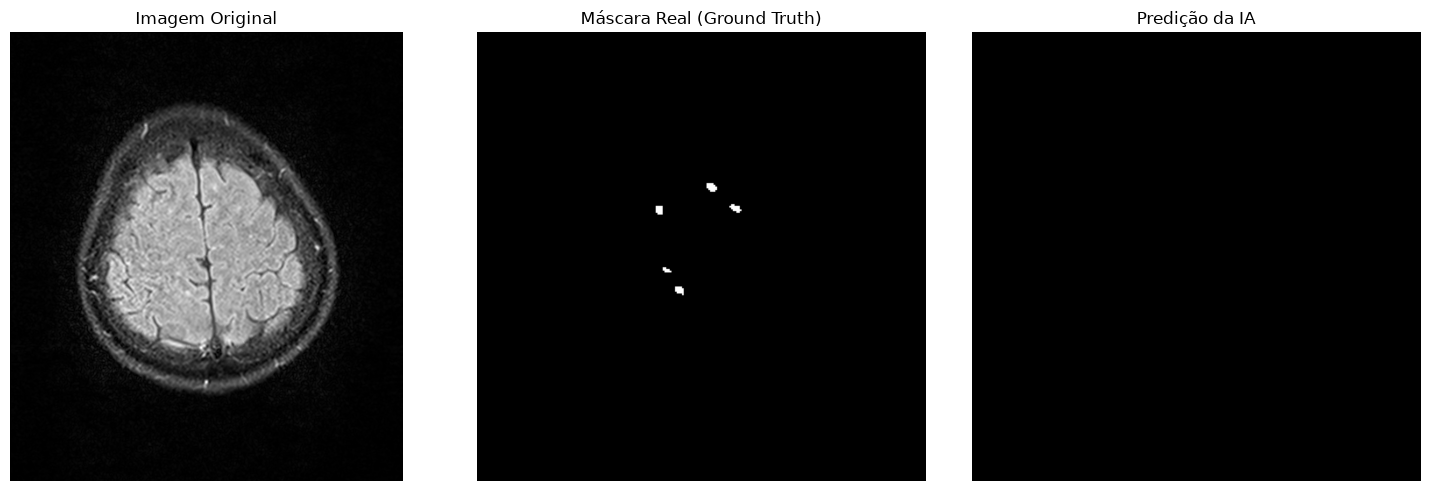

In [9]:
image_dir = "dataset/images"
mask_dir = "dataset/masks"

if os.path.exists(image_dir) and os.path.exists(mask_dir):
    images = os.listdir(image_dir)
    if images:
        # Seleciona uma imagem aleatória do dataset
        sample_img = random.choice(images)
        img_path = os.path.join(image_dir, sample_img)
        mask_path = os.path.join(mask_dir, sample_img.replace("img", "mask")) 
        
        print(f"Testando a imagem: {sample_img}")
        predict_and_visualize(img_path, mask_path)
    else:
        print("Nenhuma imagem encontrada na pasta dataset/images.")
else:
    print("Pastas do dataset não encontradas.")

## 4. Avaliação de Métricas Quantitativas (Teste de Lote)

Nesta etapa, calculamos o **Dice Score** médio iterando sobre todas as imagens disponíveis. Isso nos dá uma visão quantitativa do quão bem a IA está segmentando os objetos de interesse no dataset atual.

In [10]:
def evaluate_metrics():
    if not (os.path.exists(image_dir) and os.path.exists(mask_dir)):
        print("Pastas do dataset não encontradas.")
        return
        
    images = os.listdir(image_dir)
    if not images:
        print("Nenhuma imagem para avaliar.")
        return
        
    total_dice = 0.0
    count = 0
    
    for img_name in images:
        img_path = os.path.join(image_dir, img_name)
        mask_path = os.path.join(mask_dir, img_name.replace("img", "mask"))
        
        if not os.path.exists(mask_path):
            continue
            
        image = Image.open(img_path).convert("L")
        mask = Image.open(mask_path).convert("L")
        
        input_tensor = img_transform(image).unsqueeze(0).to(device)
        target_tensor = mask_transform(mask).unsqueeze(0).to(device)
        target_tensor = (target_tensor > 0.5).float()
        
        with torch.no_grad():
            output = model(input_tensor)
            probs = torch.sigmoid(output)
            pred = (probs > 0.5).float()
            
            intersection = (pred * target_tensor).sum()
            union = pred.sum() + target_tensor.sum()
            dice = (2. * intersection) / (union + 1e-6)
            
            total_dice += dice.item()
            count += 1
            
    if count > 0:
        avg_dice = total_dice / count
        print(f"Avaliação finalizada com sucesso em {count} imagens.")
        print(f"🏆 Dice Score Médio Global: {avg_dice:.4f}")
    else:
        print("Nenhuma imagem válida com máscara correspondente foi encontrada.")
        
evaluate_metrics()

Avaliação finalizada com sucesso em 992 imagens.
🏆 Dice Score Médio Global: 0.0080


Além da avaliação visual, foi realizada uma análise quantitativa utilizando o Dice Score médio calculado sobre todas as imagens do conjunto de teste. Essa métrica fornece uma medida objetiva da qualidade da segmentação produzida pelo modelo, considerando simultaneamente os acertos e os erros na sobreposição entre as máscaras preditas e reais. Valores mais próximos de 1 indicam maior precisão na segmentação.

O Dice Score é uma das métricas mais utilizadas em tarefas de segmentação de imagens médicas por medir diretamente a sobreposição entre a segmentação prevista pelo modelo e a máscara de referência. Seu valor varia entre 0 e 1, onde 0 representa ausência de sobreposição e 1 representa correspondência perfeita entre as duas segmentações.